<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [1]:
# Your code here
import pandas as pd

df = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

cols = ["fare_amount", "tip_amount", "tolls_amount", "total_amount"]

summary_stats = df[cols].describe()

summary_stats


,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [3]:
# Your code here
longest_trip = df.loc[df["trip_distance"].idxmax()]

longest_trip_amounts = longest_trip[["fare_amount", "tip_amount", "tolls_amount", "total_amount"]]

longest_trip_amounts

fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object

<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [4]:
# Your code here
meteorites = pd.read_csv("data/Meteorite_Landings.csv")

meteorites = meteorites.rename(columns={"mass (g)": "mass"})
meteorites = meteorites.drop(columns=["reclat", "reclong"], errors="ignore")

meteorites_sorted = meteorites.sort_values(by="mass", ascending=False)

meteorites_sorted.head()



,name,id,nametype,recclass,mass,fall,year,GeoLocation
16392,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,01/01/1920 12:00:00 AM,"(-19.58333, 17.91667)"
5373,Cape York,5262,Valid,"Iron, IIIAB",58200000.0,Found,01/01/1818 12:00:00 AM,"(76.13333, -64.93333)"
5365,Campo del Cielo,5247,Valid,"Iron, IAB-MG",50000000.0,Found,12/22/1575 12:00:00 AM,"(-27.46667, -60.58333)"
5370,Canyon Diablo,5257,Valid,"Iron, IAB-MG",30000000.0,Found,01/01/1891 12:00:00 AM,"(35.05, -111.03333)"
3455,Armanty,2335,Valid,"Iron, IIIE",28000000.0,Found,01/01/1898 12:00:00 AM,"(47.0, 88.0)"


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [ ]:


meteorites = pd.read_csv("data/Meteorite_Landings.csv")

meteorites["year"] = pd.to_datetime(meteorites["year"], errors="coerce")

meteorites["year"] = meteorites["year"].dt.year

meteorites["before_1970"] = meteorites["year"] < 1970

meteorites = meteorites.set_index("id").sort_index()

subset = meteorites.loc[10036:10040]

subset


,name,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation,before_1970
id,,,,,,,,,,
10036,Enigma,Valid,H4,94.0,Found,1967.0,31.33333,-82.31667,"(31.33333, -82.31667)",True
10037,Enon,Valid,"Iron, ungrouped",763.0,Found,1883.0,39.86667,-83.95000,"(39.86667, -83.95)",True
10038,Enshi,Valid,H5,8000.0,Fell,1974.0,30.30000,109.50000,"(30.3, 109.5)",False
10039,Ensisheim,Valid,LL6,127000.0,Fell,NaN,47.86667,7.35000,"(47.86667, 7.35)",False


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [ ]:
# Your code here
errors = meteorites[(meteorites["year"] < 1400) | (meteorites["year"] > 2025)]




There's a meteorite that was reportedly found in the future:

In [16]:
# Your code here
errors[["name", "year"]]

,name,year
id,,
57150,Northwest Africa 7701,2101.0


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [ ]:
# Your code here
pickup_col = "tpep_pickup_datetime" if "tpep_pickup_datetime" in df.columns else "pickup_datetime"
df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")

df["hour"] = df[pickup_col].dt.hour

by_hour = (
    df.groupby("hour", dropna=True)[["fare_amount", "total_amount", "tip_amount"]]
        .sum(min_count=1)   # keeps NaN if all were NaN in a group
        .sort_values("tip_amount", ascending=False)
)

top5_tip_hours = by_hour.head(5)

by_hour, top5_tip_hours

(      fare_amount  total_amount  tip_amount
 hour                                       
 16      133897.07     200350.51    23488.44
 17       14529.16      21507.98     2453.91
 15        1970.00       2947.71      339.60
 13         173.50        222.56       26.86
 14         116.50        167.56       16.66
 12          23.00         37.25        5.65
 8          138.50        156.70        5.50
 18          18.50         35.72        4.32
 7          138.90        153.00        4.00
 9           58.00         67.60        0.00,
       fare_amount  total_amount  tip_amount
 hour                                       
 16      133897.07     200350.51    23488.44
 17       14529.16      21507.98     2453.91
 15        1970.00       2947.71      339.60
 13         173.50        222.56       26.86
 14         116.50        167.56       16.66)

<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

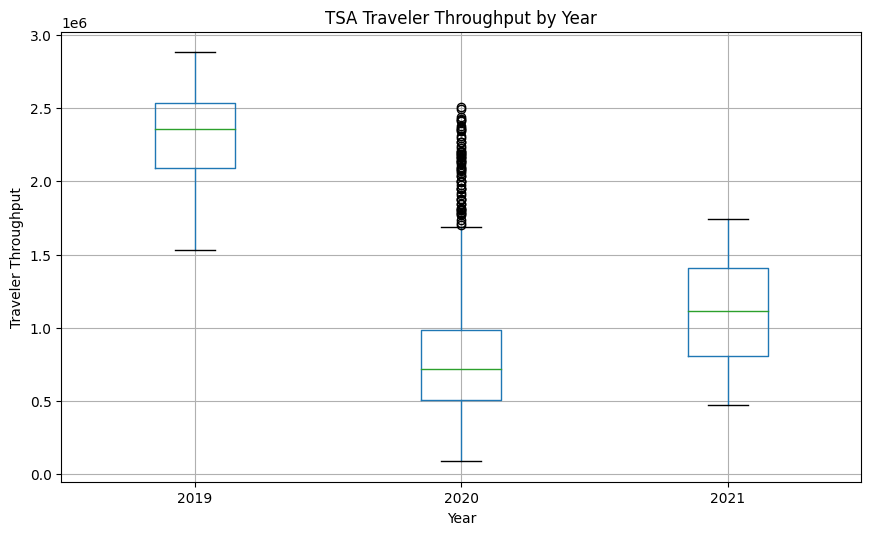

In [28]:
# Your code here
import matplotlib.pyplot as plt

tsa = pd.read_csv("data/tsa_melted_holiday_travel.csv")




tsa.boxplot(column="travelers", by="year", figsize=(10,6))

plt.title("TSA Traveler Throughput by Year")
plt.suptitle("")  # removes the extra subtitle
plt.xlabel("Year")
plt.ylabel("Traveler Throughput")
plt.show()


<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

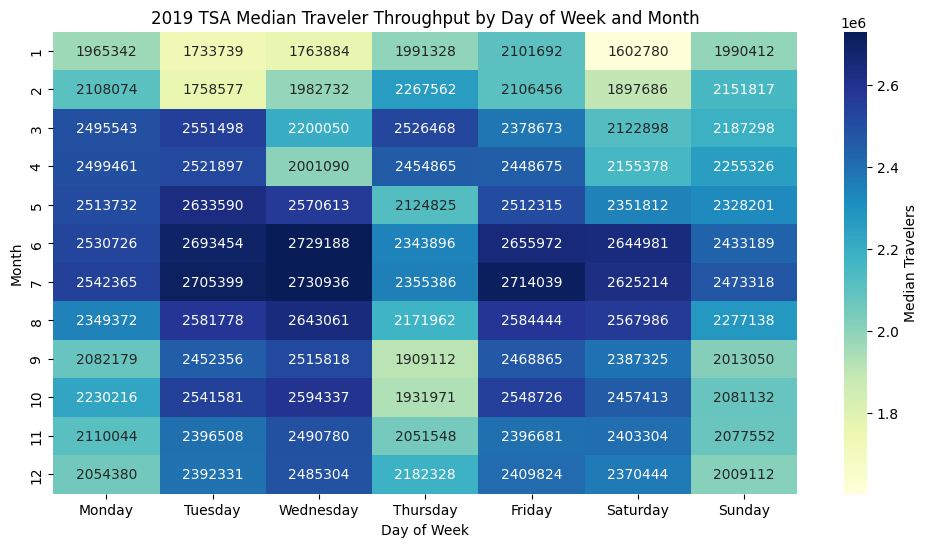

In [30]:
# Your code here
import seaborn as sns
import matplotlib.pyplot as plt


tsa_2019 = tsa[tsa["year"] == 2019].copy()

tsa_2019["date"] = pd.to_datetime(tsa_2019["date"])

tsa_2019["day_of_week"] = tsa_2019["date"].dt.day_name()
tsa_2019["month"] = tsa_2019["date"].dt.month

heatmap_data = tsa_2019.groupby(["month", "day_of_week"])["travelers"].median().unstack()

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data[days_order]

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Median Travelers'})
plt.title("2019 TSA Median Traveler Throughput by Day of Week and Month")
plt.xlabel("Day of Week")
plt.ylabel("Month")
plt.show()
